In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# Load data

In [32]:
SUBSAMPLED_TESTF1_PATH  = Path("../results/testf1_subsampling.csv")
FULL_TESTF1_PATH  = Path("../results/testf1_full.csv")
REL_F1_PATH  = Path("../results/rel_f1_all.csv")

df = pd.read_csv(SUBSAMPLED_TESTF1_PATH)
df_full = pd.read_csv(FULL_TESTF1_PATH)
df_rel = pd.read_csv(REL_F1_PATH) 

# PLOT

# Definitions and Functions

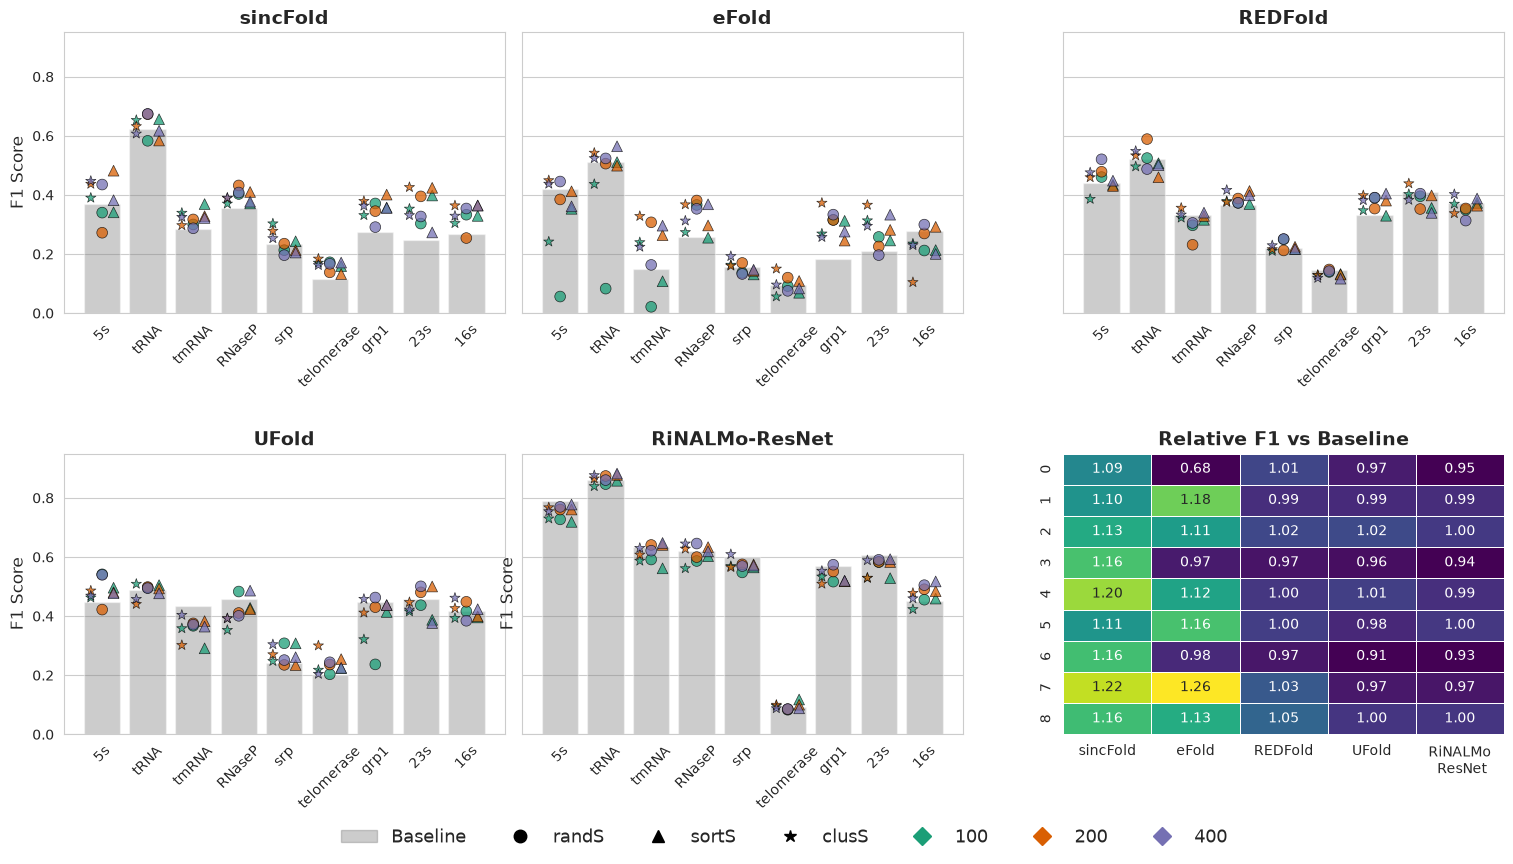

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec  
 
 
PALETTE = {100: "#1B9E77", 200: "#D95F02", 400: "#7570B3"}
MARKERS = {"randS": "o", "sortS": "^", "clusS": "*"}

fams = ['5s', 'tRNA',  'tmRNA',   'RNaseP','srp',  'telomerase', 'grp1', '23s', '16s']
fam_map = {f: i for i, f in enumerate(fams)}
sns.set_style("whitegrid")



def strip(ax, df, fam_map):  
    delta = 0.25
    ds = 3*delta / len(df.groupby("strategy")) if len(df.groupby("strategy")) != 0 else 0  
    x = df["fam"].map(fam_map) - delta 
    # plot
    for strategy, g in df.groupby("strategy"):
        ax.scatter(
            x[g.index],
            g["test_f1"],
            marker=MARKERS[strategy],
            c=[PALETTE[u] for u in g["K"]],
            edgecolors="k",
            lw=0.5,
            s=60,
            alpha=0.75,
            label=strategy,
        )
        x += ds  # move x to the next strategy 

 
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 4, figure=fig, 
                       width_ratios=[1, 1, 0.15, 1], 
                       wspace=0.05,                  
                       hspace=0.5)                   
 
plot_coords = [
    (0, 0), (0, 1), (0, 3), # Row 0: Mod0, Mod1, --, Mod2
    (1, 0), (1, 1)          # Row 1: Mod3, Mod4, --, (Heatmap in 1,3)
]

subplot_axes = []
# 1. bar plots + strip plots  
for i, model in enumerate(df_full["model"].unique()):
    row, col = plot_coords[i]
    
    ax = fig.add_subplot(gs[row, col])
    subplot_axes.append(ax)

    # full model baseline (gray bar)
    sns.barplot(data=df_full.loc[df_full["model"] == model], x="fam", y="test_f1", color="gray", order=fams, alpha=0.4, errorbar=None, ax=ax)
    # subsampling models (strip plot)
    strip(ax, df.loc[df["model"] == model], fam_map)
 
    ax.set_ylim(0, 0.95)
    ax.set_title(f"{model}", fontsize=14, fontweight='bold')
    ax.set_xlabel("")
    ax.set_xticks(range(len(fams)))
    ax.set_xticklabels(fams, fontsize=10, rotation=45)

    if (i != 0) and (i != 3):
        ax.sharey(subplot_axes[0])
        if col != 0:
            plt.setp(ax.get_yticklabels(), visible=False)
            ax.set_ylabel("")
    else: 
        ax.set_ylabel("F1 Score", fontsize=12)

    if ax.get_legend():
        ax.get_legend().remove()

ax.set_ylabel("F1 Score", fontsize=12)

# 2. HEATMAP (1, 3)
ax_heat = fig.add_subplot(gs[1, 3])
sns.heatmap(
    df_rel,
    annot=True, fmt=".2f", cmap="viridis", linewidths=0.5,
    cbar=False, vmin=0.95, vmax=1.25,
    ax=ax_heat, annot_kws={"size": 10}
)
ax_heat.set_title("Relative F1 vs Baseline", fontsize=14, fontweight='bold')
ax_heat.set_ylabel("")
ax_heat.set_xlabel("")
ax_heat.tick_params(left=False, bottom=False)

# 3. LEYEND
h_baseline = [Patch(color='gray', alpha=0.4, label='Baseline')]
h_shapes = [Line2D([], [], color='black', marker=marker, linestyle='', markersize=9, label=name) for name, marker in MARKERS.items()]
h_colors = [Line2D([], [], color=color, marker='D', linestyle='', markersize=9, label=f"{thr}") for thr, color in PALETTE.items()]

legend_handles = h_baseline + h_shapes + h_colors

fig.legend(
    handles=legend_handles,
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.023),
    ncol=7, 
    frameon=False, 
    fontsize=13
)

plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.12)
plt.show()